# EDA — bureau.csv

## Step 1 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded")

Libraries loaded


## Step 2 — Load Data

In [7]:
df = pd.read_csv("data/application_train.csv")
df.columns = df.columns.str.lower().str.strip()
if "target" in df.columns:
    df = df.rename(columns={"target": "default"})

bureau = pd.read_csv("data/bureau.csv")
bureau.columns = bureau.columns.str.lower().str.strip()

print("application_train shape:", df.shape)
print("bureau shape           :", bureau.shape)

application_train shape: (307511, 122)
bureau shape           : (1716428, 17)


## Step 3 

In [9]:
bureau.head()

,sk_id_curr,sk_id_bureau,credit_active,credit_currency,days_credit,credit_day_overdue,days_credit_enddate,days_enddate_fact,amt_credit_max_overdue,cnt_credit_prolong,amt_credit_sum,amt_credit_sum_debt,amt_credit_sum_limit,amt_credit_sum_overdue,credit_type,days_credit_update,amt_annuity
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [10]:
print("=== COLUMNS ===")
print(bureau)
print()
print("=== DATA TYPES ===")
print(bureau.dtypes.value_counts())

=== COLUMNS ===
         sk_id_curr  sk_id_bureau credit_active credit_currency  days_credit  \
0            215354       5714462        Closed      currency 1         -497   
1            215354       5714463        Active      currency 1         -208   
2            215354       5714464        Active      currency 1         -203   
3            215354       5714465        Active      currency 1         -203   
4            215354       5714466        Active      currency 1         -629   
...             ...           ...           ...             ...          ...   
1716423      259355       5057750        Active      currency 1          -44   
1716424      100044       5057754        Closed      currency 1        -2648   
1716425      100044       5057762        Closed      currency 1        -1809   
1716426      246829       5057770        Closed      currency 1        -1878   
1716427      246829       5057778        Closed      currency 1         -463   

         credit_day_ove

## Step 4 — Basic Statistics

In [15]:
bureau.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sk_id_curr,1716428.0,278214.93,102938.56,100001.00,188866.75,278055.0,367426.00,4.562550e+05
sk_id_bureau,1716428.0,5924434.49,532265.73,5000000.00,5463953.75,5926303.5,6385681.25,6.843457e+06
days_credit,1716428.0,-1142.11,795.16,-2922.00,-1666.00,-987.0,-474.00,0.000000e+00
credit_day_overdue,1716428.0,0.82,36.54,0.00,0.00,0.0,0.00,2.792000e+03
days_credit_enddate,1610875.0,510.52,4994.22,-42060.00,-1138.00,-330.0,474.00,3.119900e+04
days_enddate_fact,1082775.0,-1017.44,714.01,-42023.00,-1489.00,-897.0,-425.00,0.000000e+00
amt_credit_max_overdue,591940.0,3825.42,206031.61,0.00,0.00,0.0,0.00,1.159872e+08
cnt_credit_prolong,1716428.0,0.01,0.10,0.00,0.00,0.0,0.00,9.000000e+00
amt_credit_sum,1716415.0,354994.59,1149811.34,0.00,51300.00,125518.5,315000.00,5.850000e+08
amt_credit_sum_debt,1458759.0,137085.12,677401.13,-4705600.32,0.00,0.0,40153.50,1.701000e+08


## Step 5 — Records Per Applicant

In [18]:
print("Unique applicants in bureau:", bureau["sk_id_curr"].nunique())
print("Unique credit records      :", bureau["sk_id_bureau"].nunique())
print("Average credits per person :", round(
    len(bureau) / bureau["sk_id_curr"].nunique(), 2))

Unique applicants in bureau: 305811
Unique credit records      : 1716428
Average credits per person : 5.61


count    305811.00
mean          5.61
std           4.43
min           1.00
25%           2.00
50%           4.00
75%           8.00
max         116.00
Name: sk_id_bureau, dtype: float64


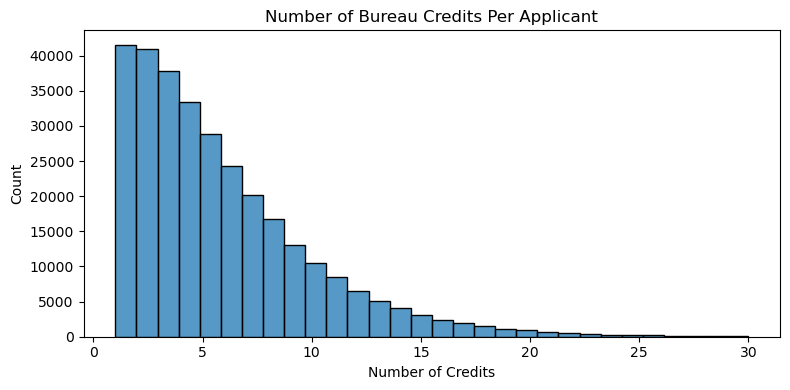

In [20]:
credits_per_person = bureau.groupby("sk_id_curr")["sk_id_bureau"].count()

print(credits_per_person.describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(credits_per_person[credits_per_person <= 30], bins=30)
plt.title("Number of Bureau Credits Per Applicant")
plt.xlabel("Number of Credits")
plt.tight_layout()
plt.show()

## Step 6 — Missing Values

Columns with missing values: 6

amt_annuity               71.47
amt_credit_max_overdue    65.51
days_enddate_fact         36.92
amt_credit_sum_limit      34.48
amt_credit_sum_debt       15.01
days_credit_enddate        6.15
dtype: float64


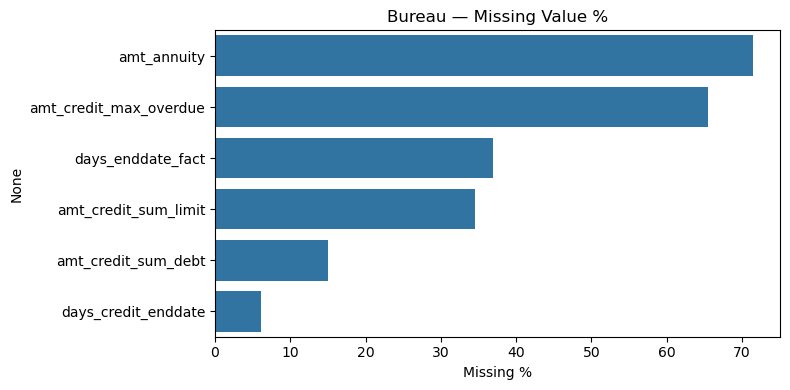

In [23]:
missing_b = (bureau.isnull().sum() / len(bureau) * 100).round(2)
missing_b = missing_b[missing_b > 0].sort_values(ascending=False)

print("Columns with missing values:", len(missing_b))
print()
print(missing_b)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_b.values, y=missing_b.index)
plt.title("Bureau — Missing Value %")
plt.xlabel("Missing %")
plt.tight_layout()
plt.show()

## Step 7 — Distribution of Key Columns

=== CREDIT ACTIVE STATUS ===
credit_active
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64

credit_active
Closed      62.88
Active      36.74
Sold         0.38
Bad debt     0.00
Name: proportion, dtype: float64


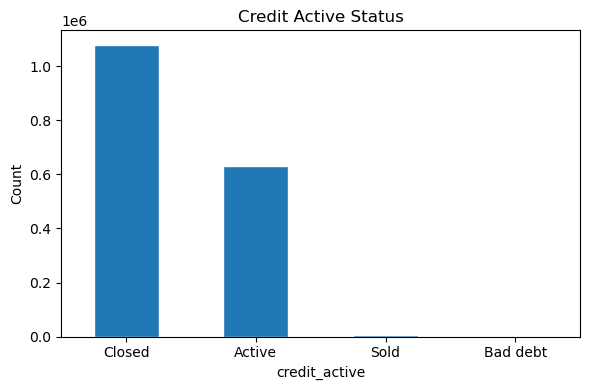

In [26]:
print("=== CREDIT ACTIVE STATUS ===")
print(bureau["credit_active"].value_counts())
print()
print((bureau["credit_active"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
bureau["credit_active"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Credit Active Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== CREDIT TYPES ===
credit_type
Consumer credit                                 1251615
Credit card                                      402195
Car loan                                          27690
Mortgage                                          18391
Microloan                                         12413
Loan for business development                      1975
Another type of loan                               1017
Unknown type of loan                                555
Loan for working capital replenishment              469
Cash loan (non-earmarked)                            56
Real estate loan                                     27
Loan for the purchase of equipment                   19
Loan for purchase of shares (margin lending)          4
Mobile operator loan                                  1
Interbank credit                                      1
Name: count, dtype: int64


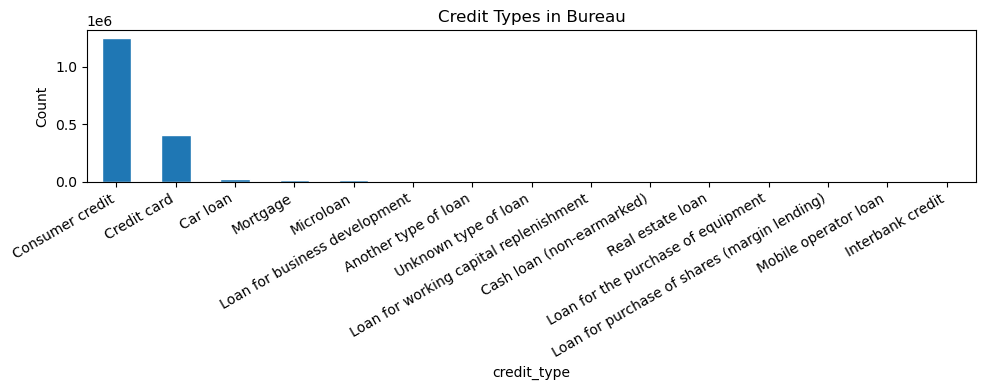

In [28]:
print("=== CREDIT TYPES ===")
print(bureau["credit_type"].value_counts())

plt.figure(figsize=(10, 4))
bureau["credit_type"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Credit Types in Bureau")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [30]:
print("=== CREDIT DAY OVERDUE ===")
print(bureau["credit_day_overdue"].describe().round(2))

overdue = (bureau["credit_day_overdue"] > 0).sum()
print()
print("Credits with overdue days:", overdue,
      f"({round(overdue / len(bureau) * 100, 2)}%)")

print()
print("=== CURRENT DEBT ===")
print(bureau["amt_credit_sum_debt"].describe().round(2))

active_debt = (bureau["amt_credit_sum_debt"] > 0).sum()
print()
print("Credits with active debt:", active_debt,
      f"({round(active_debt / len(bureau) * 100, 2)}%)")

=== CREDIT DAY OVERDUE ===
count    1716428.00
mean           0.82
std           36.54
min            0.00
25%            0.00
50%            0.00
75%            0.00
max         2792.00
Name: credit_day_overdue, dtype: float64

Credits with overdue days: 4217 (0.25%)

=== CURRENT DEBT ===
count    1.458759e+06
mean     1.370851e+05
std      6.774011e+05
min     -4.705600e+06
25%      0.000000e+00
50%      0.000000e+00
75%      4.015350e+04
max      1.701000e+08
Name: amt_credit_sum_debt, dtype: float64

Credits with active debt: 433907 (25.28%)


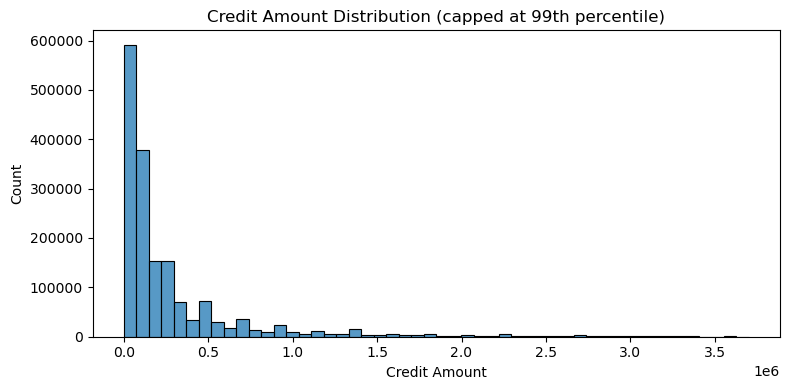

In [32]:
q99 = bureau["amt_credit_sum"].quantile(0.99)

plt.figure(figsize=(8, 4))
sns.histplot(bureau[bureau["amt_credit_sum"] <= q99]["amt_credit_sum"], bins=50)
plt.title("Credit Amount Distribution (capped at 99th percentile)")
plt.xlabel("Credit Amount")
plt.tight_layout()
plt.show()

## Step 8 — Relationship with Target

In [35]:
main_ids   = set(df["sk_id_curr"])
bureau_ids = set(bureau["sk_id_curr"])

matched  = len(main_ids & bureau_ids)
no_match = len(main_ids - bureau_ids)

print("Have bureau records :", matched,
      f"({round(matched / len(main_ids) * 100, 2)}%)")
print("No bureau records   :", no_match,
      f"({round(no_match / len(main_ids) * 100, 2)}%)")

has_bureau = df[df["sk_id_curr"].isin(bureau_ids)]
no_bureau  = df[~df["sk_id_curr"].isin(bureau_ids)]

print()
print("Default rate WITH bureau records   :",
      round(has_bureau["default"].mean() * 100, 2), "%")
print("Default rate WITHOUT bureau records:",
      round(no_bureau["default"].mean() * 100, 2), "%")

Have bureau records : 263491 (85.69%)
No bureau records   : 44020 (14.31%)

Default rate WITH bureau records   : 7.73 %
Default rate WITHOUT bureau records: 10.12 %


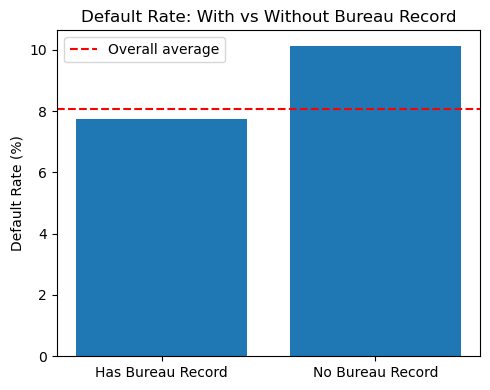

In [37]:
plt.figure(figsize=(5, 4))
bars = plt.bar(
    ["Has Bureau Record", "No Bureau Record"],
    [has_bureau["default"].mean() * 100,
     no_bureau["default"].mean() * 100]
)
plt.title("Default Rate: With vs Without Bureau Record")
plt.ylabel("Default Rate (%)")
plt.axhline(df["default"].mean() * 100, color="red",
            linestyle="--", label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()

Bureau merged with target shape: (1465325, 18)

=== DEFAULT RATE BY CREDIT ACTIVE STATUS ===
credit_active
Bad debt    20.00
Sold        10.10
Active       9.29
Closed       6.93
Name: default, dtype: float64


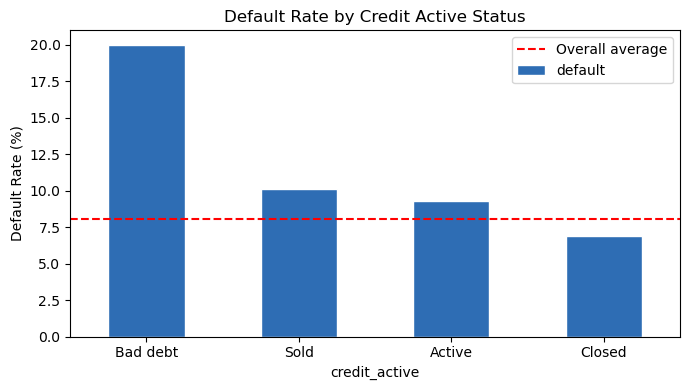


=== DEFAULT RATE BY CREDIT TYPE ===
credit_type
Loan for the purchase of equipment              23.53
Microloan                                       20.64
Loan for working capital replenishment          12.73
Credit card                                      8.80
Consumer credit                                  7.48
Another type of loan                             7.14
Loan for business development                    6.16
Unknown type of loan                             6.14
Car loan                                         5.57
Mortgage                                         5.00
Cash loan (non-earmarked)                        4.35
Interbank credit                                 0.00
Loan for purchase of shares (margin lending)     0.00
Mobile operator loan                             0.00
Real estate loan                                 0.00
Name: default, dtype: float64


In [42]:
# Merge target from main dataset into bureau
# This lets us check how bureau features relate to default directly

bureau_merged = df[["sk_id_curr", "default"]].merge(
    bureau, on="sk_id_curr", how="inner"
)

print("Bureau merged with target shape:", bureau_merged.shape)

# Default rate by credit active status
credit_default = (
    bureau_merged.groupby("credit_active")["default"]
    .mean() * 100
).round(2).sort_values(ascending=False)

print("\n=== DEFAULT RATE BY CREDIT ACTIVE STATUS ===")
print(credit_default)

plt.figure(figsize=(7, 4))
credit_default.plot(kind="bar", color="#2E6DB4", edgecolor="white")
plt.axhline(df["default"].mean() * 100, color="red",
            linestyle="--", label="Overall average")
plt.title("Default Rate by Credit Active Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# Default rate by credit type
credit_type_default = (
    bureau_merged.groupby("credit_type")["default"]
    .mean() * 100
).round(2).sort_values(ascending=False)

print("\n=== DEFAULT RATE BY CREDIT TYPE ===")
print(credit_type_default)

## Step 9 — Outlier Check

In [45]:
b_num = bureau.select_dtypes(include=np.number).columns.tolist()
excl  = ["sk_id_curr", "sk_id_bureau"]
check = [c for c in b_num if c not in excl]

print(f"Checking {len(check)} columns\n")
print(f"{'Column':<35} {'1%':>12} {'99%':>12} {'Max':>15} {'Outlier?'}")
print("-" * 85)

outlier_cols = []
for col in check:
    q01     = bureau[col].quantile(0.01)
    q99     = bureau[col].quantile(0.99)
    max_val = bureau[col].max()
    is_out  = (max_val > q99 * 3) if q99 > 0 else (
               max_val > 100 if q99 == 0 else False)
    flag    = "YES" if is_out else "ok"
    if is_out:
        outlier_cols.append(col)
    print(f"{col:<35} {q01:>12.2f} {q99:>12.2f} {max_val:>15.2f}  {flag}")

print()
print("Outlier columns:")
for c in outlier_cols:
    print(" -", c)

Checking 12 columns

Column                                        1%          99%             Max Outlier?
-------------------------------------------------------------------------------------
days_credit                             -2867.00       -38.00            0.00  ok
credit_day_overdue                          0.00         0.00         2792.00  YES
days_credit_enddate                     -2571.00     31029.00        31199.00  ok
days_enddate_fact                       -2639.00       -24.00            0.00  ok
amt_credit_max_overdue                      0.00     41988.75    115987185.00  YES
cnt_credit_prolong                          0.00         0.00            9.00  ok
amt_credit_sum                              0.00   3700916.10    585000000.00  YES
amt_credit_sum_debt                         0.00   2259728.46    170100000.00  YES
amt_credit_sum_limit                        0.00    199620.56      4705600.32  YES
amt_credit_sum_overdue                      0.00         0.00  

## Observations

- 1,716,428 credit records, 17 columns. Average 5.61 credits per applicant.
- 85.69% of applicants have bureau records. 14.31% have no bureau history.
- Applicants WITHOUT bureau records default MORE: 10.12% vs 7.73%.
- Absence of credit history is itself a risk signal.
- amt_annuity has 71.47% missing — will be dropped.
- Only 0.25% of credits have overdue days but maximum is 2,792 days.
- 25.28% of credits have active outstanding debt.
- amt_credit_sum_debt negative values mean unused credit limit — not an error.
- print("\n=== KEY OBSERVATIONS ===")
- Bad debt status: 20.00% — highest risk group, 2.5x overall average")
print("Active credits : 9.29%  — more debt elsewhere = more pressure = higher risk")
print("Closed credits : 6.93%  — fully repaid borrowers = lowest risk")
print()
print("Microloan: 20.64% — small unsecured loans carry highest risk")
print("Mortgage : 5.00%  — property backed loans carry lowest risk")
print("Insight: asset-backed credit = lower default, unsecured = higher default")